In [36]:
import os
import json
import requests
from typing import Dict, List, Any, Optional, TypedDict, Tuple, Literal

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from models.report_service_manager import ServiceManager
from models.llm_service_manager import BrainManager

In [37]:
# Initialize service managers
report_manager = ServiceManager()
brain_manager = BrainManager()

# Define our state
class AgentState(TypedDict):
    messages: List[Dict[str, Any]]
    weather_data: Optional[Dict[str, Any]]
    news_data: Optional[Dict[str, Any]]
    jobs_data: Optional[Dict[str, Any]]
    command: Optional[str]
    tool_input: Optional[Dict[str, Any]]
    intent: Optional[str]

In [38]:
# API communication functions
def send_to_llm(messages: List[Dict[str, str]]) -> str:
    """Send messages to the Ollama API wrapper and get a response"""
    # Ensure the API wrapper is running
    if not brain_manager.ensure_api_running():
        return "Error: Unable to connect to LLM service"
        
    # Format messages for the API
    formatted_messages = []
    for msg in messages:
        formatted_messages.append({
            "role": msg["role"],
            "content": msg["content"]
        })
    
    # Use stream-chat endpoint since it's working better
    try:
        response = requests.post(
            "http://localhost:8000/stream-chat",
            json={"messages": formatted_messages, "temperature": 0.7, "max_tokens": 1000},
            stream=True
        )
        
        if response.status_code == 200:
            # Collect the full response from the stream
            full_response = ""
            for line in response.iter_lines():
                if line:
                    # SSE format is "data: {...}"
                    if line.startswith(b'data: '):
                        data = line[6:]  # Skip "data: "
                        if data == b'[DONE]':
                            break
                        try:
                            chunk = json.loads(data)
                            if 'text' in chunk:
                                full_response += chunk['text']
                        except json.JSONDecodeError:
                            continue
            
            return full_response
        else:
            return f"Error communicating with LLM: {response.status_code}"
    except requests.RequestException as e:
        return f"Request to LLM failed: {str(e)}"
    except Exception as e:
        return f"Unexpected error with LLM: {str(e)}"

In [39]:
def get_weather(location: str = None, days: int = 7) -> Dict[str, Any]:
    """Get weather forecast for a location"""
    # Only start the service when this function is actually called
    weather_url = report_manager.ensure_service_running("weather")
    if not weather_url:
        return {"error": "Weather service unavailable"}
    
    # Default to Seattle if no location provided
    if not location:
        location = "Seattle"
    
    # Convert location to lat/long (simplified for example)
    locations = {
        "Seattle": "47.69,-122.1808",
        "New York": "40.7128,-74.0060",
        "San Francisco": "37.7749,-122.4194"
    }
    
    coordinates = locations.get(location, "47.69,-122.1808")  # Default to Seattle
    
    try:
        response = requests.get(f"{weather_url}/weather/{coordinates},{days}")
        if response.status_code == 200:
            return response.json()
        else:
            return {"error": f"Weather API error: {response.status_code}"}
    except requests.RequestException as e:
        return {"error": f"Request failed: {str(e)}"}

def get_news(query: str, category: str = None) -> Dict[str, Any]:
    """Get news articles based on query and optional category"""
    # Only start the service when this function is actually called
    news_url = report_manager.ensure_service_running("news")
    if not news_url:
        return {"error": "News service unavailable"}
    
    params = {}
    if query:
        params["keywords"] = query
    if category:
        params["category"] = category
    
    try:
        response = requests.get(f"{news_url}/news", params=params)
        if response.status_code == 200:
            return response.json()
        else:
            return {"error": f"News API error: {response.status_code}"}
    except requests.RequestException as e:
        return {"error": f"Request failed: {str(e)}"}

def search_jobs(job_title: str, location: str = None, field: str = None) -> Dict[str, Any]:
    """Search for jobs based on title, location, and field"""
    # Only start the service when this function is actually called
    jobs_url = report_manager.ensure_service_running("jobs")
    if not jobs_url:
        return {"error": "Jobs service unavailable"}
    
    params = {"job_title": job_title}
    if location:
        params["location"] = location
    if field:
        params["field"] = field
    
    try:
        response = requests.get(f"{jobs_url}/jobs", params=params)
        if response.status_code == 200:
            return response.json()
        else:
            return {"error": f"Jobs API error: {response.status_code}"}
    except requests.RequestException as e:
        return {"error": f"Request failed: {str(e)}"}

In [40]:
# ================= LangGraph Nodes =================
def intent_detection_node(state: AgentState) -> AgentState:
    """Determine user intent using the LLM"""
    print("Entering intent_detection_node")
    
    # Ensure all required keys exist in state
    if "messages" not in state:
        state["messages"] = []
    
    messages = state["messages"]
    
    # Extract the latest user message
    latest_user_msg = None
    for msg in reversed(messages):
        if msg["role"] == "user":
            latest_user_msg = msg["content"]
            break
    
    if not latest_user_msg:
        state["messages"].append({"role": "assistant", "content": "I'm not sure what you're asking for."})
        return state
    
    print(f"Processing user message: {latest_user_msg[:50]}...")
    
    # Create a prompt specifically for intent detection
    llm_messages = [
        {
            "role": "system", 
            "content": """You are an intent detection assistant. 
            Analyze the user's request and determine which category it falls into.
            Respond with just one of the following intents:
            - INTENT: WEATHER - if the user is asking about weather, temperature, forecast, etc.
            - INTENT: NEWS - if the user is asking about news, current events, headlines, articles, etc.
            - INTENT: JOBS - if the user is asking about jobs, career opportunities, positions, etc.
            - INTENT: DAILY_REPORT - if the user is asking for a summary, daily report, or update on multiple topics
            - INTENT: CONVERSATION - for any other request, general conversation, or greetings
            
            Only respond with the intent, nothing else."""
        },
        {"role": "user", "content": latest_user_msg}
    ]
    
    # Get intent from LLM
    intent_response = send_to_llm(llm_messages)
    
    # Extract intent from response
    intent = "CONVERSATION"  # Default
    if "INTENT: WEATHER" in intent_response.upper():
        intent = "WEATHER"
    elif "INTENT: NEWS" in intent_response.upper():
        intent = "NEWS"
    elif "INTENT: JOBS" in intent_response.upper():
        intent = "JOBS"
    elif "INTENT: DAILY_REPORT" in intent_response.upper():
        intent = "DAILY_REPORT"
    
    # Store the detected intent in state
    state["intent"] = intent
    print(f"Detected intent: {intent}")
    
    # Return the updated state
    return state
# def intent_detection_node(state: AgentState) -> Dict:
#     """Determine if user intent is for a specialized service or general conversation"""
#     # Ensure all required keys exist in state
#     if "messages" not in state:
#         state["messages"] = []
    
#     messages = state["messages"]
    
#     # Extract the latest user message
#     latest_user_msg = None
#     for msg in reversed(messages):
#         if msg["role"] == "user":
#             latest_user_msg = msg["content"]
#             break
    
#     if not latest_user_msg:
#         state["messages"].append({"role": "assistant", "content": "I'm not sure what you're asking for."})
#         return {"next": "END"}
    
#     # Create a prompt specifically for intent detection
#     llm_messages = [
#         {
#             "role": "system", 
#             "content": """You are an intent detection assistant. 
#             Analyze the user's request and determine which category it falls into.
#             Respond with just one of the following intents:
#             - INTENT: WEATHER - if the user is asking about weather, temperature, forecast, etc.
#             - INTENT: NEWS - if the user is asking about news, current events, headlines, articles, etc.
#             - INTENT: JOBS - if the user is asking about jobs, career opportunities, positions, etc.
#             - INTENT: DAILY_REPORT - if the user is asking for a summary, daily report, or update on multiple topics
#             - INTENT: CONVERSATION - for any other request, general conversation, or greetings
            
#             Only respond with the intent, nothing else."""
#         },
#         {"role": "user", "content": latest_user_msg}
#     ]
    
#     # Get intent from LLM
#     intent_response = send_to_llm(llm_messages)
    
#     # Extract intent from response
#     intent = "CONVERSATION"  # Default
#     if "INTENT: WEATHER" in intent_response.upper():
#         intent = "WEATHER"
#     elif "INTENT: NEWS" in intent_response.upper():
#         intent = "NEWS"
#     elif "INTENT: JOBS" in intent_response.upper():
#         intent = "JOBS"
#     elif "INTENT: DAILY_REPORT" in intent_response.upper():
#         intent = "DAILY_REPORT"
    
#     # Store the detected intent in state
#     state["intent"] = intent
#     print(f"Detected intent: {intent}")
    
#     # No explicit routing - will use conditional edge
#     return {}


def conversation_node(state: AgentState) -> Dict:
    """Handle general conversation requests (including greetings)"""
    # Get response directly from LLM
    llm_messages = [
        {
            "role": "system", 
            "content": "You are a helpful assistant. Provide clear and concise responses to the user's questions. If they are greeting you, respond with a friendly greeting."
        }
    ]
    
    # Add conversation history
    for msg in state["messages"]:
        llm_messages.append(msg)
    
    llm_response = send_to_llm(llm_messages)
    state["messages"].append({"role": "assistant", "content": llm_response})
    return {"next": "END"}

In [49]:
def weather_node(state: AgentState) -> Dict:
    """Process weather requests"""
    # Ensure all required keys exist
    if "tool_input" not in state:
        state["tool_input"] = {}
    if "weather_data" not in state:
        state["weather_data"] = None
    
    tool_input = state["tool_input"]
    location = tool_input.get("location", "Seattle")
    
    print(f"Getting weather for {location}")
    
    # Call weather API
    weather_data = get_weather(location)
    state["weather_data"] = weather_data
    
    # Format response
    if "error" in weather_data:
        response = f"Sorry, I couldn't get the weather information: {weather_data['error']}"
    else:
        location = weather_data.get("location", "the requested location")
        forecast = weather_data.get("forecast", [])
        if forecast:
            response = f"Weather forecast for {location}:\n\n"
            for day in forecast[:3]:  # Show first 3 days
                date = day.get("name", "")
                temp = day.get("temperature", "")
                condition = day.get("shortForecast", "")
                response += f"• {date}: {temp}°F, {condition}\n"
        else:
            response = f"Weather data for {location} is available, but no forecast details were found."
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": "END"}

def news_node(state: AgentState) -> Dict:
    """Process news requests"""
    # Ensure all required keys exist
    if "tool_input" not in state:
        state["tool_input"] = {}
    if "news_data" not in state:
        state["news_data"] = None
    
    tool_input = state["tool_input"]
    query = tool_input.get("query", "technology")
    
    print(f"Getting news about {query}")
    
    # Call news API
    news_data = get_news(query)
    state["news_data"] = news_data
    
    # Format response
    if "error" in news_data:
        response = f"Sorry, I couldn't find news: {news_data['error']}"
    else:
        articles = news_data.get("result", [])
        if articles:
            response = f"Here are some recent news about '{query}':\n\n"
            for i, article in enumerate(articles[:3], 1):
                title = article.get("title", "Untitled")
                source = article.get("source", "Unknown source")
                response += f"{i}. {title} ({source})\n"
            response += f"\nFound {len(articles)} articles in total."
        else:
            response = f"I didn't find any news articles about '{query}'."
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": "END"}

# Additional nodes
def jobs_node(state: AgentState) -> Dict:
    """Process job search requests"""
    # Ensure all required keys exist
    if "tool_input" not in state:
        state["tool_input"] = {}
    if "jobs_data" not in state:
        state["jobs_data"] = None
    
    tool_input = state["tool_input"]
    job_title = tool_input.get("job_title", "Data Scientist")
    location = tool_input.get("location")
    
    print(f"Searching for {job_title} jobs{' in ' + location if location else ''}")
    
    # Call jobs API (only when actually needed)
    jobs_data = search_jobs(job_title, location)
    state["jobs_data"] = jobs_data
    
    # Format response
    if "error" in jobs_data:
        response = f"Sorry, I couldn't find jobs: {jobs_data['error']}"
    else:
        jobs = jobs_data.get("result", [])
        if jobs:
            location_str = f" in {location}" if location else ""
            response = f"Here are some recent {job_title} jobs{location_str}:\n\n"
            for i, job in enumerate(jobs[:3], 1):
                title = job.get("title", "Untitled")
                company = job.get("company", "Unknown company")
                job_location = job.get("location", "")
                response += f"{i}. {title} at {company} ({job_location})\n"
            response += f"\nFound {len(jobs)} jobs in total."
        else:
            response = f"I didn't find any {job_title} jobs{' in ' + location if location else ''}."
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": "END"}

def daily_report_node(state: AgentState) -> Dict:
    """Process requests for a combined daily report with weather, news, and jobs"""
    # Ensure all required keys exist
    if "tool_input" not in state:
        state["tool_input"] = {}
    if "weather_data" not in state:
        state["weather_data"] = None
    if "news_data" not in state:
        state["news_data"] = None
    if "jobs_data" not in state:
        state["jobs_data"] = None
    
    tool_input = state["tool_input"]
    weather_location = tool_input.get("weather_location", "Seattle")
    news_query = tool_input.get("news_query", "technology")
    job_title = tool_input.get("job_title", "Data Scientist")
    job_location = tool_input.get("job_location")
    
    print("Generating daily report...")
    
    # Call all three APIs in sequence (only when actually needed)
    weather_data = get_weather(weather_location)
    news_data = get_news(news_query)
    jobs_data = search_jobs(job_title, job_location)
    
    # Store data in state
    state["weather_data"] = weather_data
    state["news_data"] = news_data
    state["jobs_data"] = jobs_data
    
    # Format combined response
    response = "📋 Your Daily Report\n\n"
    
    # Add weather section
    response += "🌤️ WEATHER FORECAST\n"
    if "error" in weather_data:
        response += f"Sorry, I couldn't get the weather information: {weather_data['error']}\n\n"
    else:
        location = weather_data.get("location", weather_location)
        forecast = weather_data.get("forecast", [])
        if forecast:
            response += f"Weather for {location}:\n"
            for day in forecast[::]:  # Show first 2 days
                date = day.get("name", "")
                temp = day.get("temperature", "")
                condition = day.get("shortForecast", "")
                response += f"• {date}: {temp}°F, {condition}\n"
        else:
            response += f"Weather data for {location} is available, but no forecast details were found.\n"
    response += "\n"
    
    # Add news section
    response += "📰 NEWS UPDATES\n"
    if "error" in news_data:
        response += f"Sorry, I couldn't find news: {news_data['error']}\n\n"
    else:
        articles = news_data.get("result", [])
        if articles:
            response += f"Top news about '{news_query}':\n"
            for i, article in enumerate(articles[:5], 1):
                title = article.get("title", "Untitled")
                source = article.get("source", "Unknown source")
                response += f"{i}. {title} ({source})\n"
        else:
            response += f"I didn't find any news articles about '{news_query}'.\n"
    response += "\n"
    
    # Add jobs section
    response += "💼 JOB OPPORTUNITIES\n"
    if "error" in jobs_data:
        response += f"Sorry, I couldn't find jobs: {jobs_data['error']}\n"
    else:
        jobs = jobs_data.get("result", [])
        if jobs:
            location_str = f" in {job_location}" if job_location else ""
            response += f"Recent {job_title} jobs{location_str}:\n"
            for i, job in enumerate(jobs[:10], 1):
                title = job.get("title", "Untitled")
                company = job.get("company", "Unknown company")
                job_location = job.get("location", "")
                response += f"{i}. {title} at {company} ({job_location})\n"
        else:
            response += f"I didn't find any {job_title} jobs{' in ' + job_location if job_location else ''}.\n"
    
    state["messages"].append({"role": "assistant", "content": response})
    return {"next": "END"}
# Add a new greeting node to handle simple hellos
def greeting_node(state: AgentState) -> Dict:
    """Handle simple greetings"""
    greeting_response = "Hello! I can help you with weather forecasts, news updates, and job searches. What would you like to know?"
    state["messages"].append({"role": "assistant", "content": greeting_response})
    return {"next": "END"}

In [50]:
# --------------Conditional Edges---------------------#
# Define a router function that determines next step after intent detection
# Define a proper routing function
def router(state: AgentState) -> Literal["conversation_node", "weather_node", "news_node", "jobs_node", "daily_report_node"]:
    """Route based on the detected intent"""
    intent = state.get("intent", "CONVERSATION")
    print(f"Router: Routing based on intent '{intent}'")
    
    if intent == "WEATHER":
        return "weather_node"
    elif intent == "NEWS":
        return "news_node"
    elif intent == "JOBS":
        return "jobs_node"
    elif intent == "DAILY_REPORT":
        return "daily_report_node"
    else:
        return "conversation_node"
# def intent_router(state: AgentState) -> str:
#     """Route to the appropriate node based on detected intent"""
#     intent = state.get("intent", "CONVERSATION")
    
#     if intent == "WEATHER":
#         return "weather_node"
#     elif intent == "NEWS":
#         return "news_node"
#     elif intent == "JOBS":
#         return "jobs_node"
#     elif intent == "DAILY_REPORT":
#         return "daily_report_node"
#     else:
#         # Everything else (including GREETING) is just conversation
#         return "conversation_node"

In [51]:
# # Testing intent_detection
# state = {"messages":[{"role":"user", "content":"I need full report today."}]}
# intent_detection_node(state)

In [52]:
# state = {"messages":[{"role":"user", "content":"I need full report today."}]}
# conversation_node(state)
# print("Updated state after conversation:")
# for message in state["messages"]:
#     print(f"{message['role']}: {message['content']}")

In [53]:
# Create new graph with proper conditional routing
workflow = StateGraph(AgentState)

# Add all nodes
workflow.add_node("intent_detection_node", intent_detection_node)
workflow.add_node("conversation_node", conversation_node)
workflow.add_node("weather_node", weather_node)
workflow.add_node("news_node", news_node)
workflow.add_node("jobs_node", jobs_node)
workflow.add_node("daily_report_node", daily_report_node)

# Start with intent detection
workflow.add_edge(START, "intent_detection_node")

# Set up the conditional edge with a properly typed router function
workflow.add_conditional_edges(
    "intent_detection_node",
    router,
    {
        "conversation_node": "conversation_node",
        "weather_node": "weather_node",
        "news_node": "news_node",
        "jobs_node": "jobs_node",
        "daily_report_node": "daily_report_node"
    }
)

# Make sure all nodes end properly
workflow.add_edge("conversation_node", END)
workflow.add_edge("weather_node", END)
workflow.add_edge("news_node", END)
workflow.add_edge("jobs_node", END)
workflow.add_edge("daily_report_node", END)

# Compile the graph
app = workflow.compile()
print("Graph compiled successfully!")

Graph compiled successfully!


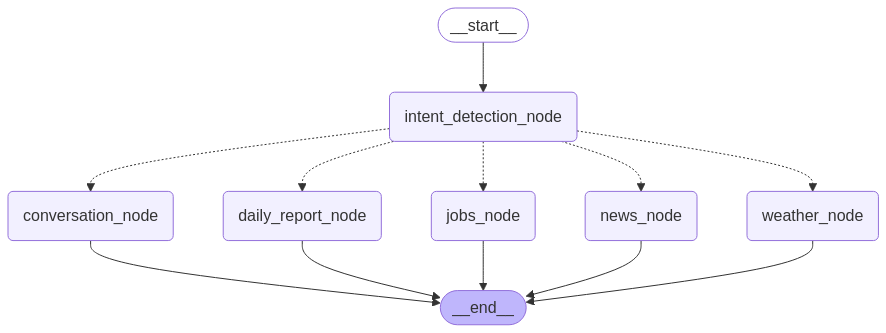

In [54]:
# Visualizing the graph using get_graph and one the "draw" method like "draw_ascii" or "draw_png"
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [55]:
# Configuration for LangGraph
config = {"configurable": {"thread_id": 1}}

# Helper function to chat with the agent
def chat(user_input: str, state: Optional[Dict] = None) -> Dict:
    """Process a user message and return the updated state"""
    if state is None:
        state = {
            "messages": [],
            "weather_data": None,
            "news_data": None, 
            "jobs_data": None,
            "command": None,
            "tool_input": {}
        }
    
    # Add user message to state
    state["messages"].append({"role": "user", "content": user_input})
    
    # Process through graph
    result = app.invoke(state, config=config)
    
    return result

In [56]:
# Main execution
if __name__ == "__main__":
    try:
        print("Starting services...")
        
        # Make sure LLM services are running
        brain_manager.ensure_services_running()
        print("LLM services are running")
        
        # Start conversation
        state = {
            "messages": [],
            "weather_data": None,
            "news_data": None, 
            "jobs_data": None,
            "command": None,
            "tool_input": {},
            "intent": None
        }
        
        print("\nAI Assistant: Hello! I can help you with weather forecasts, news updates, and job searches. What would you like to know?")
        
        while True:
            user_input = input("\nYou: ")
            if user_input.lower() in ["exit", "quit", "bye"]:
                break
                
            state = chat(user_input, state)
            
            # Print assistant's response
            for message in state["messages"]:
                if message["role"] == "assistant" and message.get("content"):
                    print(f"\nAI Assistant: {message['content']}")
    
    finally:
        # Clean up by stopping all services
        print("\nStopping services...")
        report_manager.stop_all_services()
        brain_manager.stop_services()
        print("All services stopped")

Starting services...
Ollama service is already running
API wrapper is already running
LLM services are running

AI Assistant: Hello! I can help you with weather forecasts, news updates, and job searches. What would you like to know?
Entering intent_detection_node
Processing user message: I need a daily report: Weather for seattle, news o...
API wrapper is already running
Detected intent: DAILY_REPORT
Router: Routing based on intent 'DAILY_REPORT'
Generating daily report...
Starting weather service on port 8001...
weather service is running now.
Starting news service on port 8002...
news service is running now.
Starting jobs service on port 8003...
jobs service is running now.

AI Assistant: 📋 Your Daily Report

🌤️ WEATHER FORECAST
Weather for Kirkland, WA:
• Overnight: 43°F, Light Rain Likely
• Friday: 50°F, Light Rain then Showers And Thunderstorms
• Friday Night: 39°F, Showers And Thunderstorms then Light Rain
• Saturday: 52°F, Light Rain Likely
• Saturday Night: 43°F, Light Rain
• S